In [1]:
### imports

import os
import numpy as np
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
from osgeo import gdal

import pygmt

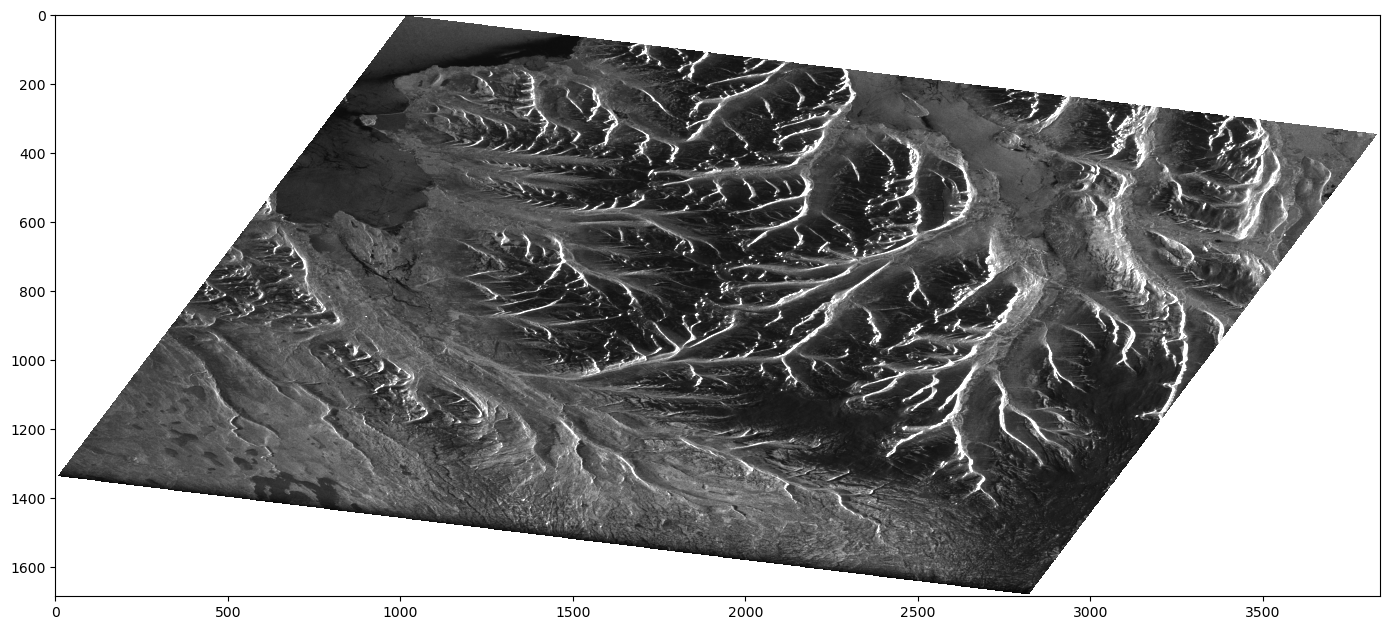

In [7]:
import os
import numpy as np
from matplotlib.pypot import figure, show
import matplotlib.pyplot as plt
from osgeo import gdal

ds1 = gdal.Open("preview/reference_preview.tif", gdal.GA_ReadOnly)
slc1 = ds1.GetRasterBand(1).ReadAsArray()
ds1 = None

fig = plt.figure(figsize=(14, 12))l

# display amplitude of the slc
fr = fig.add_subplot(1,1,1)

image1 = fr.imshow(np.abs(slc1), vmin = 0, vmax=5, cmap='gray')


fig.tight_layout()

plt.show()

slc = None

[[ 70  64  73 ... 154 136   0]
 [ 76  90 113 ... 163 125   0]
 [ 86 125  97 ... 161 149   0]
 ...
 [ 35  39  41 ...  32  27   0]
 [ 36  41  40 ...  31  34   0]
 [ 36  36  36 ...  33  34   0]]


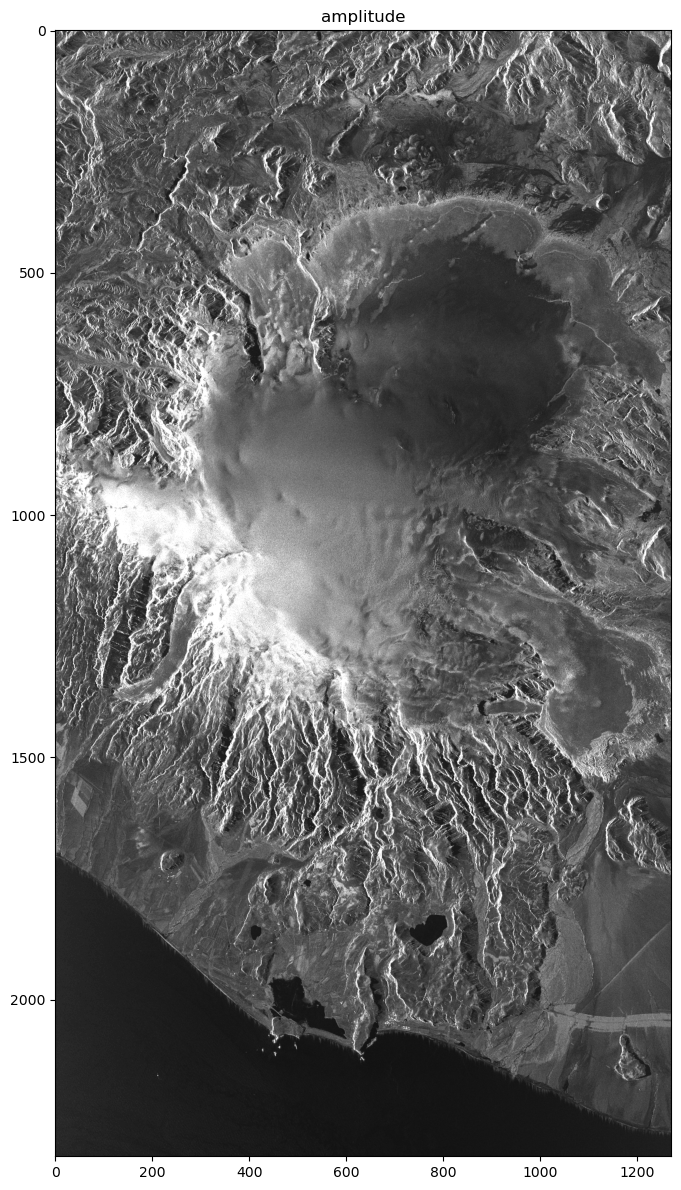

In [7]:
ds = gdal.Open("/home/data/TSX/South/T41_s011_6345_Katla/20100621/TSX-1.SAR.L1B/TSX1_SAR__SSC______SM_S_SRA_20100621T184736_20100621T184744/PREVIEW/COMPOSITE_QL.tif", gdal.GA_ReadOnly)
x0 = 0
y0 = 0
x_offset = 16382
y_offset = 24191
slc = ds.GetRasterBand(1).ReadAsArray()
ds = None

print(slc)

fig = plt.figure(figsize=(14, 12))

# display amplitude of the slc
fr = fig.add_subplot(1,1,1)
fr.imshow(slc, vmin=0, cmap='gray')
fr.set_title("amplitude")

fig.tight_layout()


plt.show()

[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


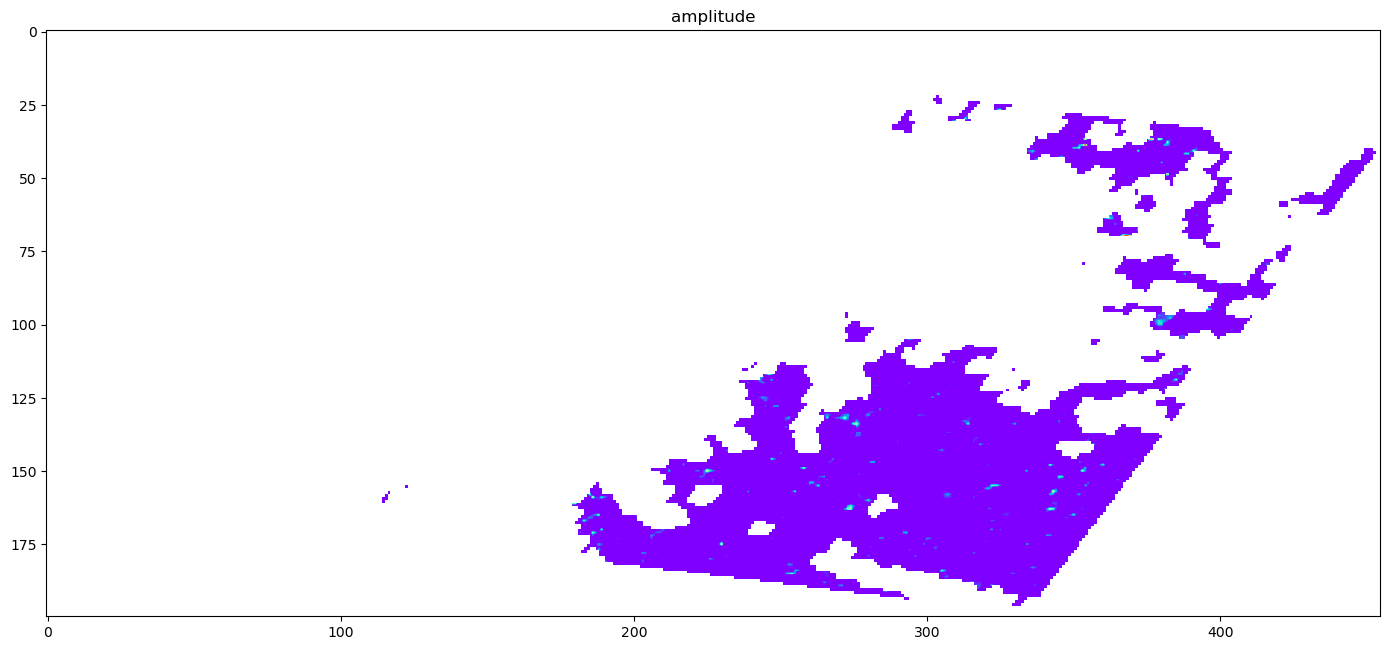

In [8]:
import os
import numpy as np
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
from osgeo import gdal

ds = gdal.Open("geocoded_offsets/autoRIFT/azimuth.tif", gdal.GA_ReadOnly)
x0 = 0
y0 = 0
x_offset = 16382
y_offset = 24191
slc = ds.GetRasterBand(1).ReadAsArray()
ds = None

print(slc)

fig = plt.figure(figsize=(14, 12))

# display amplitude of the slc
fr = fig.add_subplot(1,1,1)
fr.imshow(slc, vmin=0, cmap='rainbow')
fr.set_title("amplitude")

fig.tight_layout()


plt.show()

['/home/yad2/PixelTrackingRuns/RUN20230806-TSXSECOND/20100621-20110802', '/home/yad2/PixelTrackingRuns/RUN20230806-TSXSECOND/20110802-20150815', '/home/yad2/PixelTrackingRuns/RUN20230806-TSXSECOND/20150815-20161017', '/home/yad2/PixelTrackingRuns/RUN20230806-TSXSECOND/20161017-20170821', '/home/yad2/PixelTrackingRuns/RUN20230806-TSXSECOND/20170821-20180625', '/home/yad2/PixelTrackingRuns/RUN20230806-TSXSECOND/20180625-20200620', '/home/yad2/PixelTrackingRuns/RUN20230806-TSXSECOND/20200620-20230603']


Exception ignored on calling ctypes callback function: <function Session.create.<locals>.print_func at 0x7f2b7897d240>
Traceback (most recent call last):
  File "/home/yad2/.conda/envs/GMT/lib/python3.10/site-packages/pygmt/clib/session.py", line 367, in print_func
    @ctp.CFUNCTYPE(ctp.c_int, ctp.c_void_p, ctp.c_char_p)
KeyboardInterrupt: 


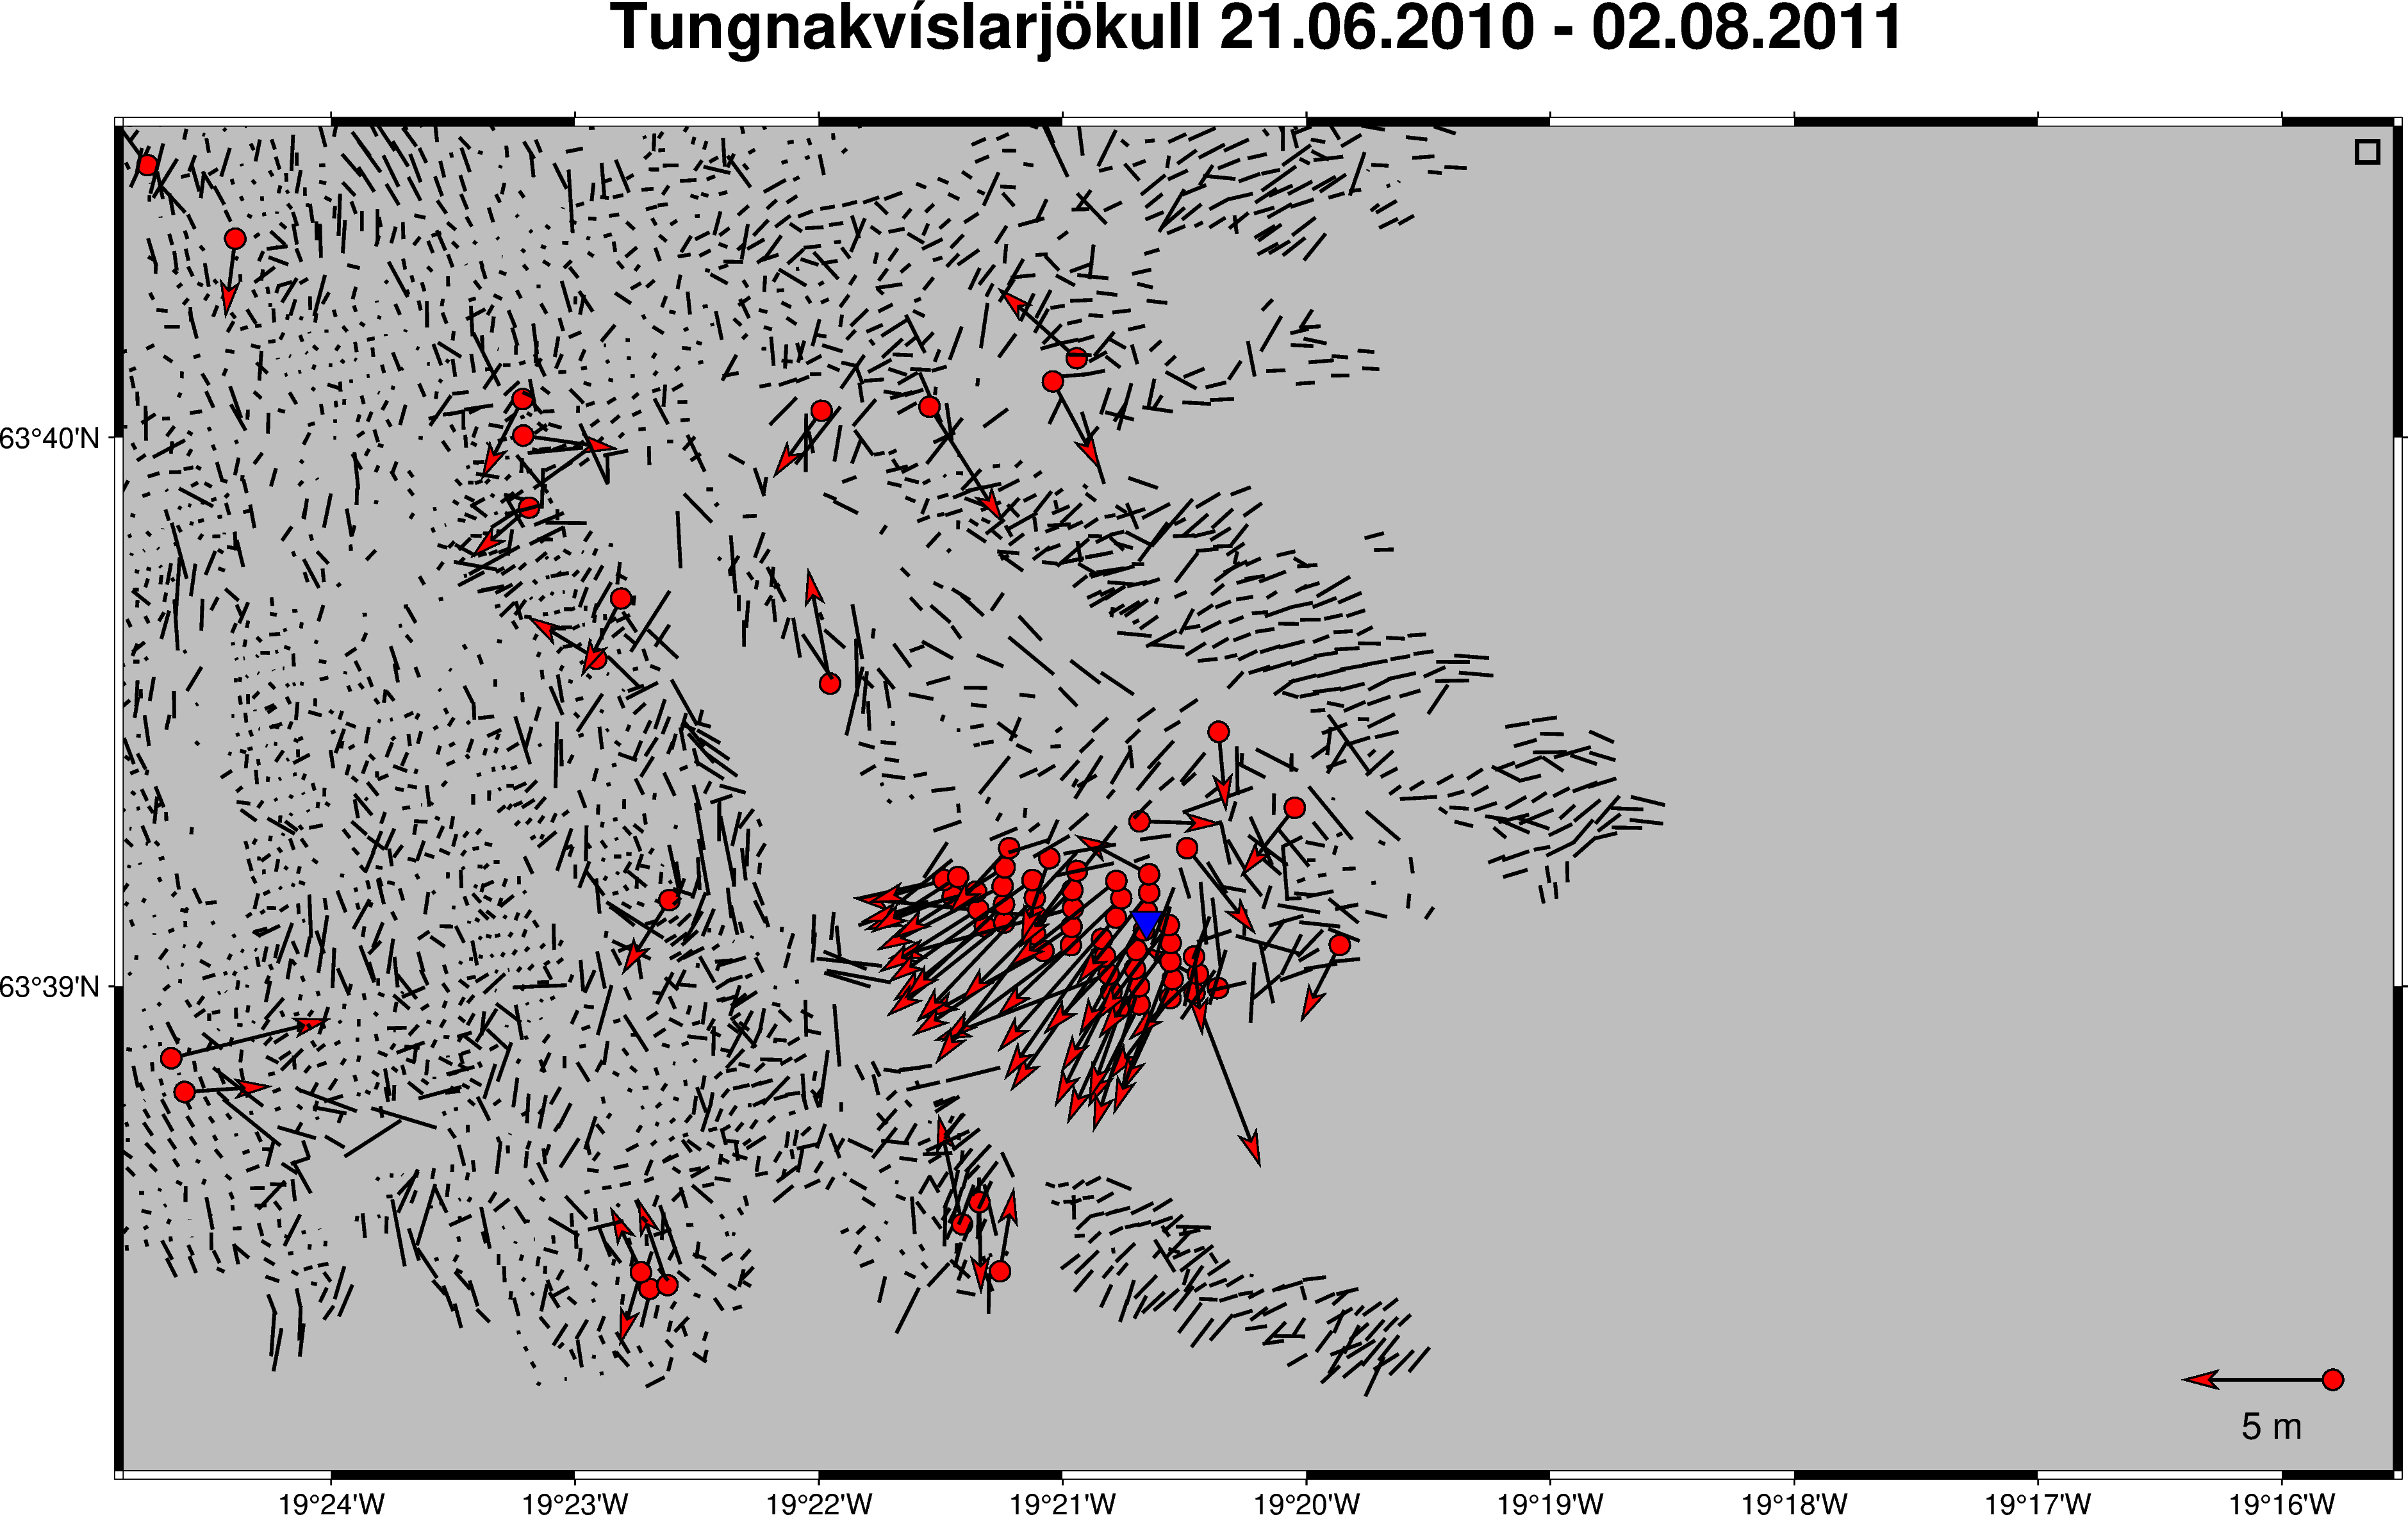

In [1]:
import pygmt
import os
import numpy as np

folders = [f.path for f in os.scandir("/home/yad2/PixelTrackingRuns/RUN20230806-TSXSECOND") if f.is_dir()]

print(folders)

for folder in folders:
    try:
        dx, dy, lat, lon, z, los, head = np.loadtxt(os.path.join(folder, 'geocoded_offsets/AutoRIFT.data'), delimiter=',', unpack=True)

        dx = dx - dx.mean()
        dy = dy - dy.mean()

        datestr = folder[-17:]

        firstdate = datestr[6:8]+'.'+datestr[4:6]+'.'+datestr[:4]
        seconddate = datestr[-2:]+'.'+datestr[-4:-2]+'.'+datestr[-8:-4]

        # max_lon = -18.901978
        # min_lon = -19.573517

        # max_lat = 66.147186
        # min_lat = 65.986741

        max_lon = -19.259033
        min_lon = -19.414215

        max_lat = 63.676115
        min_lat = 63.635284

        fig = pygmt.Figure()
        
        fig.coast(projection="M30c", region=f"{min_lon}/{max_lon}/{min_lat}/{max_lat}", frame=['a', f'+t"Tungnakvíslarjökull {firstdate} - {seconddate}"'.replace(' ', r'\040')], land="gray")

        # pygmt.makecpt(cmap="gray", series=[0, 300])
        # fig.grdimage(grid=os.path.join(folder, f"preview/reference_preview.tif"), nan_transparent=True, cmap=True)

        # pygmt.makecpt(cmap="gray", series=[0, 2000])
        # fig.grdimage(grid=os.path.join(folder, f"/home/data/DEM/LMI/ArcticDEM/v1/Iceland_10m.dem"), nan_transparent=True, cmap=True)

        lats = np.array([])
        lons = np.array([])

        directions = np.array([])
        magnitudes = np.array([])

        for i in range(len(lat)):
            if lat[i] < max_lat and lat[i] > min_lat and lon[i] < max_lon and lon[i] > min_lon:
                lats = np.append(lats, lat[i])
                lons = np.append(lons, lon[i])

                magnitude = np.sqrt(dy[i]**2 + dx[i]**2)
                
                rad = np.pi/2 - np.arctan2(dy[i], -dx[i])
                angle = np.degrees(rad) + head[i]
                
                directions = np.append(directions, angle)
                magnitudes = np.append(magnitudes, magnitude)

        maxish = magnitudes.max() - magnitudes.mean()

        scaling = 0.4

        fig.plot(x=lons, y=lats, direction=[directions, magnitudes*scaling], style="v0.5c+bc+ea+a30", fill="red", pen='1.25p')
        
        pointlat = 63.651974
        pointlon = -19.344262

        fig.plot(x=pointlon, y=pointlat, style="i0.5c", fill='blue', pen='0.5p')

        with fig.inset(position="jBR+w4/2c+o0.4c", margin=0, box="+gwhite+p1.5p,black"):
            fig.plot(x=[max_lon], y=[min_lat], direction=[[180], [5*scaling]], style="v0.5c+bc+ea+a30", fill="red", pen='1.25p', offset='-0.8/1.2')

            fig.text(x=max_lon, y=min_lat, font='14p', text='5 m', justify="CM", offset="-1.6/0.6")


        fig.legend(position="JTR+jTR+o0.2c", box=True)

        # fig.savefig(f'plots/TSX_UNG{datestr}.png')


        fig.show()
        
        fig = None
    except Exception as e: print(e)

In [1]:
import pygmt
import os
import numpy as np
from datetime import datetime

def haversine(lon1, lat1, lon2, lat2):
    """
    Check: https://stackoverflow.com/questions/15736995/how-can-i-quickly-estimate-the-distance-between-two-latitude-longitude-points
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    """
    # convert decimal degrees to radians 
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    # haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a)) 
    km = 6367 * c
    return km


class Estimation():
    # IWD. Check: https://stackoverflow.com/questions/36031338/interpolate-z-values-in-a-3d-surface-starting-from-an-irregular-set-of-points/36037288#36037288
    def __init__(self,lon,lat,values):
        self.x = lon
        self.y = lat
        self.v = values

    def estimate(self,x,y,using='ISD'):
        """
        Estimate point at coordinate x,y based on the input data for this
        class.
        """
        if using == 'ISD':
            return self._isd(x,y)

    def _isd(self,x,y):
        import geopy.distance

        #d = np.sqrt((x-self.x)**2+(y-self.y)**2)
        d =  self.x.copy()
        for i in range(len(d)):
            distance = geopy.distance.geodesic((self.x[i],self.y[i]), (x,y)).m
            d[i] = distance
        if d.min() > 0:
            v = np.sum(self.v*(1/d**4))/np.sum(1/d**4)
            return v
        else:
            return self.v[d.argmin()]
    

folders = [f.path for f in os.scandir("/home/yad2/PixelTrackingRuns/RUN20230806-TSXSECOND") if f.is_dir()]

print(folders)

mags        = np.array([])
firstdts    = np.array([])
seconddts    = np.array([])

for folder in folders:
    # try:
    try:
        dx, dy, lat, lon, z, los, head = np.loadtxt(os.path.join(folder, 'geocoded_offsets/AutoRIFT.data'), delimiter=',', unpack=True)

        # dx = dx - dx.mean()
        # dy = dy - dy.mean()

        dx = dx - np.median(dx)
        dy = dy - np.median(dy)
        
        print(folder)

        eX = Estimation(lon, lat, dx)
        eY = Estimation(lon, lat, dy)

        pointlat = 63.651974
        pointlon = -19.344262

        interp_dx = eX.estimate(pointlon, pointlat)
        interp_dy = eY.estimate(pointlon, pointlat)

        magnitude = np.sqrt(interp_dy**2 + interp_dx**2)
    except Exception as exc:
        print(exc)
        magnitude = np.nan
        

    datestr = folder[-17:]

    firstdate = datestr[:4]+'-'+datestr[4:6]+'-'+datestr[6:8]
    seconddate = datestr[-8:-4]+'-'+datestr[-4:-2]+'-'+datestr[-2:]

    begindt = datetime.fromisoformat(firstdate)
    enddt = datetime.fromisoformat(seconddate)

    print(begindt, enddt)
    
    mags = np.append(mags, magnitude)
    firstdts = np.append(firstdts, begindt)
    seconddts = np.append(seconddts, enddt)
    # except:
    #     print('no data', folder)
        
print(mags)
print(firstdts)
print(seconddts)
    



['/home/yad2/PixelTrackingRuns/RUN20230806-TSXSECOND/20100621-20110802', '/home/yad2/PixelTrackingRuns/RUN20230806-TSXSECOND/20110802-20150815', '/home/yad2/PixelTrackingRuns/RUN20230806-TSXSECOND/20150815-20161017', '/home/yad2/PixelTrackingRuns/RUN20230806-TSXSECOND/20161017-20170821', '/home/yad2/PixelTrackingRuns/RUN20230806-TSXSECOND/20170821-20180625', '/home/yad2/PixelTrackingRuns/RUN20230806-TSXSECOND/20180625-20200620', '/home/yad2/PixelTrackingRuns/RUN20230806-TSXSECOND/20200620-20230603']
/home/yad2/PixelTrackingRuns/RUN20230806-TSXSECOND/20100621-20110802
2010-06-21 00:00:00 2011-08-02 00:00:00
/home/yad2/PixelTrackingRuns/RUN20230806-TSXSECOND/20110802-20150815
2011-08-02 00:00:00 2015-08-15 00:00:00
/home/yad2/PixelTrackingRuns/RUN20230806-TSXSECOND/20150815-20161017
2015-08-15 00:00:00 2016-10-17 00:00:00
/home/yad2/PixelTrackingRuns/RUN20230806-TSXSECOND/20161017-20170821
2016-10-17 00:00:00 2017-08-21 00:00:00
/home/yad2/PixelTrackingRuns/RUN20230806-TSXSECOND/20170821

/tmp/ipykernel_14354/2448351855.py:64: UserWarning: loadtxt: input contained no data: "/home/yad2/PixelTrackingRuns/RUN20230806-TSXSECOND/20180625-20200620/geocoded_offsets/AutoRIFT.data"
  dx, dy, lat, lon, z, los, head = np.loadtxt(os.path.join(folder, 'geocoded_offsets/AutoRIFT.data'), delimiter=',', unpack=True)


2020-06-20 00:00:00 2023-06-03 00:00:00
[4.65595723 3.66856586 0.65046616 0.65085107 1.43674744        nan
 0.61033815]
[datetime.datetime(2010, 6, 21, 0, 0) datetime.datetime(2011, 8, 2, 0, 0)
 datetime.datetime(2015, 8, 15, 0, 0)
 datetime.datetime(2016, 10, 17, 0, 0)
 datetime.datetime(2017, 8, 21, 0, 0) datetime.datetime(2018, 6, 25, 0, 0)
 datetime.datetime(2020, 6, 20, 0, 0)]
[datetime.datetime(2011, 8, 2, 0, 0) datetime.datetime(2015, 8, 15, 0, 0)
 datetime.datetime(2016, 10, 17, 0, 0)
 datetime.datetime(2017, 8, 21, 0, 0) datetime.datetime(2018, 6, 25, 0, 0)
 datetime.datetime(2020, 6, 20, 0, 0) datetime.datetime(2023, 6, 3, 0, 0)]


In [2]:

pseudo_mags = []
pseudo_times = []
vels = []
cent_vels = []
cent_times = []

for i, mag in enumerate(mags):
    if mag == np.nan:
        mag = 0

    pseudo_mags.append(mag)
    pseudo_times.append(firstdts[i])


    pseudo_mags.append(mag)
    pseudo_times.append(seconddts[i])

    td = seconddts[i] - firstdts[i]

    yrs = td.days / 365.25

    cent_times.append(firstdts[i] + td/2)
    cent_vels.append(mag/yrs)

    vels.append(mag/yrs)
    vels.append(mag/yrs)


print(pseudo_mags)
print(pseudo_times)




[4.655957232718846, 4.655957232718846, 3.668565864824263, 3.668565864824263, 0.6504661632368185, 0.6504661632368185, 0.6508510700364616, 0.6508510700364616, 1.4367474404499467, 1.4367474404499467, nan, nan, 0.610338148637013, 0.610338148637013]
[datetime.datetime(2010, 6, 21, 0, 0), datetime.datetime(2011, 8, 2, 0, 0), datetime.datetime(2011, 8, 2, 0, 0), datetime.datetime(2015, 8, 15, 0, 0), datetime.datetime(2015, 8, 15, 0, 0), datetime.datetime(2016, 10, 17, 0, 0), datetime.datetime(2016, 10, 17, 0, 0), datetime.datetime(2017, 8, 21, 0, 0), datetime.datetime(2017, 8, 21, 0, 0), datetime.datetime(2018, 6, 25, 0, 0), datetime.datetime(2018, 6, 25, 0, 0), datetime.datetime(2020, 6, 20, 0, 0), datetime.datetime(2020, 6, 20, 0, 0), datetime.datetime(2023, 6, 3, 0, 0)]


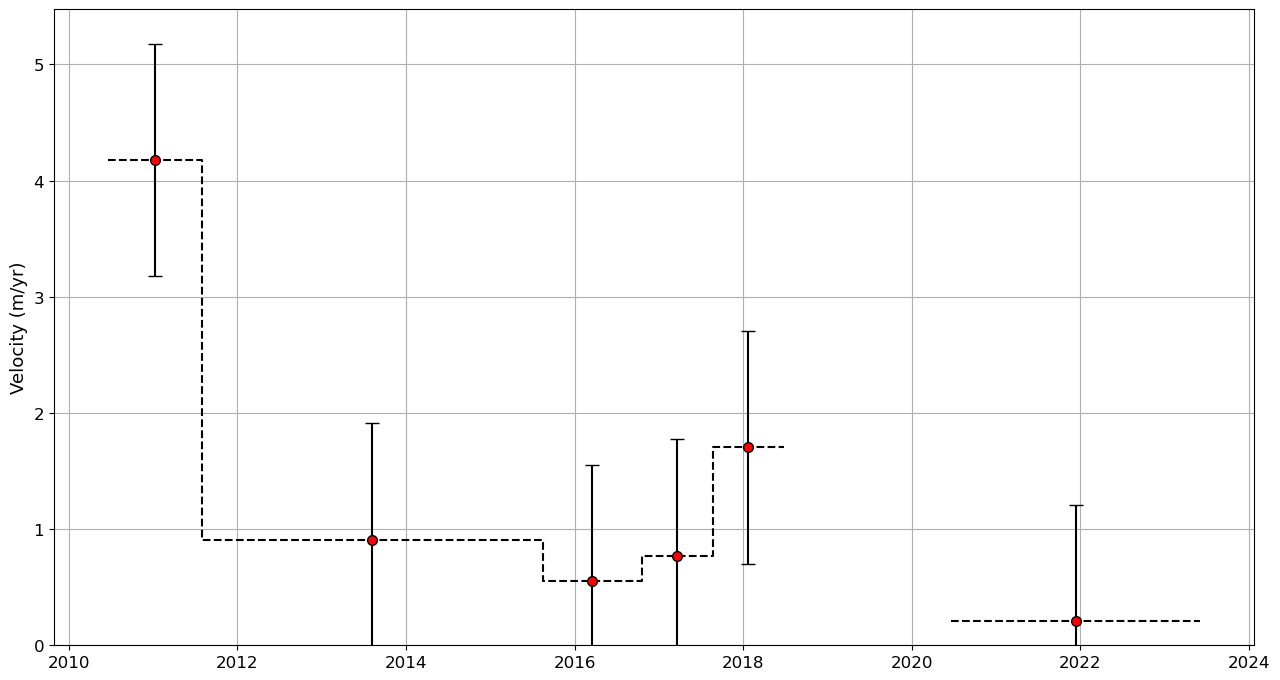

In [18]:
#Preamble

### Numpy
import numpy as np

### Time for loops
from tqdm import tqdm

### Matplotlib imports
%matplotlib inline

import matplotlib as plt

#Styling parameters
plt.rcParams['font.size'] = 13.0
plt.rcParams['xtick.labelsize'] = 12.0
plt.rcParams['ytick.labelsize'] = 12.0

plt.rcParams['axes.unicode_minus'] = False

plt.rcParams["font.family"] = "sans-serif"
# plt.rcParams["font.serif"] = 'Palatino'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

from matplotlib.pyplot import figure, show
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.dates as mdates

### Time stuff
import time
from datetime import datetime as dt


### Plotting

fig = figure(figsize=(13, 7))

fr = fig.add_subplot(1,1,1)
    
fr.plot(pseudo_times, vels, color='black', linestyle='dashed', alpha=1)

fr.errorbar(cent_times, cent_vels, yerr=1, color='red', ecolor="black", ls="none", marker='o', ms=7, mec="black", capsize=5 , alpha=1, zorder=2)

fr.set_ylim([0, None])

fr.set_xlabel(r"")
fr.set_ylabel(r"Velocity (m/yr)")

# fr.legend()

fr.grid()

fig.tight_layout()

fig.savefig("plots/TungVelTimeSeries.png", dpi=300)

show() 